# Cellular Automata: Wolfram Rules and Conway's Game of Life

A **cellular automaton** (CA) is a discrete dynamical system consisting of a grid of cells, each in a finite set of states, that evolve in discrete time steps according to a local rule depending only on the cell's own state and the states of its neighbors. Despite their simplicity, cellular automata can exhibit astonishingly complex behavior — from periodic patterns to chaos and even universal computation.

## Elementary 1D cellular automata

In an **elementary cellular automaton** (Wolfram, 1983), each cell $i$ at time $t+1$ depends on a three-cell neighborhood:
$$
x_i^{(t+1)} = f\!\left(x_{i-1}^{(t)},\, x_i^{(t)},\, x_{i+1}^{(t)}\right),
$$
where $x_i \in \{0,1\}$ (binary states) and $f$ is a Boolean function of 3 inputs. There are $2^3 = 8$ possible input patterns, each mapped to 0 or 1, giving $2^8 = 256$ distinct rules, numbered 0–255 by reading the output bits as a binary number.

Wolfram's famous **classification** groups these into four classes:
- **Class I**: converge to a uniform state.
- **Class II**: generate stable or periodic structures.
- **Class III**: apparently chaotic, aperiodic (e.g. Rule 30).
- **Class IV**: complex, localized structures — Rule 110 is **Turing complete**.

## Conway's Game of Life

In the 2D **Game of Life** (Conway, 1970), each cell has 8 neighbors (Moore neighborhood) and the evolution rule is:
- A **live cell** survives if it has exactly 2 or 3 live neighbors; otherwise it dies.
- A **dead cell** is born if it has exactly 3 live neighbors.

Despite having only two states and a simple rule, the Game of Life supports an extraordinary zoo of structures: **still lifes**, **oscillators**, **gliders**, and even **universal computers**.

This notebook constructs and visualizes both families, explores the 256-rule space interactively, and demonstrates well-known Game of Life patterns.

## Environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from ipywidgets import interact, IntSlider, Dropdown

plt.rcParams["figure.dpi"] = 120

## Rule lookup table

A rule number $r \in [0, 255]$ encodes a Boolean function of 3 bits. The three-cell pattern $(x_{i-1}, x_i, x_{i+1})$ interpreted as a 3-bit integer $c = x_{i-1} + 2x_i + 4x_{i+1}$ selects bit $c$ of $r$:
$$
x_i^{(t+1)} = \left\lfloor r / 2^c \right\rfloor \bmod 2.
$$

Each rule can be visualized as a lookup table showing the 8 local patterns and their output.

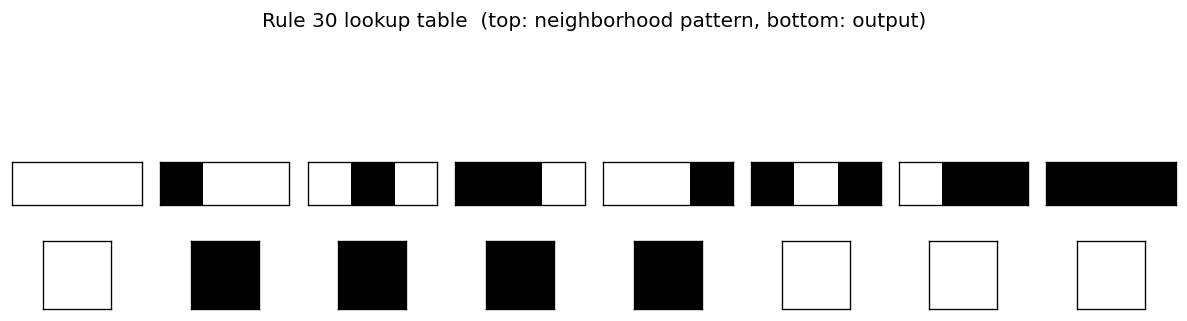

In [2]:
def make_rule(r):
    """Return an 8-element lookup table for rule r."""
    return np.array([(r >> c) & 1 for c in range(8)], dtype=np.uint8)


def show_rule_table(r):
    """Visualize the lookup table for a given rule."""
    table = make_rule(r)
    fig, axes = plt.subplots(2, 8, figsize=(10, 2.5),
                              gridspec_kw={"height_ratios": [3, 1]})
    for c in range(8):
        bits = [(c >> k) & 1 for k in range(3)]  # left, center, right
        pattern = np.array(bits).reshape(1, 3)
        axes[0, c].imshow(pattern, cmap="gray_r", vmin=0, vmax=1,
                          interpolation="nearest")
        axes[0, c].set_xticks([]); axes[0, c].set_yticks([])
        out = np.array([[table[c]]])
        axes[1, c].imshow(out, cmap="gray_r", vmin=0, vmax=1,
                          interpolation="nearest")
        axes[1, c].set_xticks([]); axes[1, c].set_yticks([])
    fig.suptitle(f"Rule {r} lookup table  (top: neighborhood pattern, bottom: output)",
                 y=1.05)
    plt.tight_layout()
    plt.show()


show_rule_table(30)

## Space–time diagram: Rule 30 (chaotic)

Starting from a single live cell at the center, we iterate the rule for $k$ steps and stack the configurations as rows to form a **space–time diagram**. Rule 30 generates a seemingly random pattern (it was used as a pseudorandom number generator in Mathematica for many years).

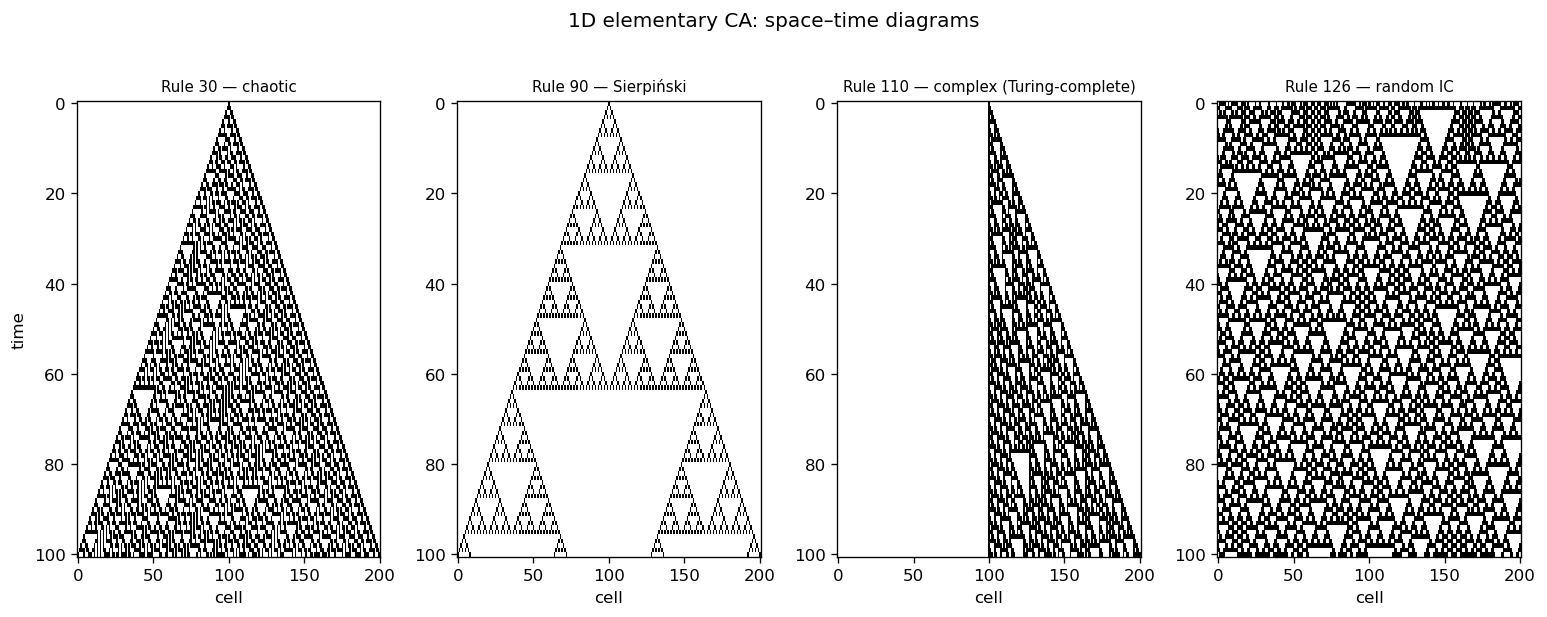

In [3]:
def run_ca1d(rule_num, n=201, k=100, init="center", seed=0):
    """Run 1D elementary CA for k generations on n cells.
    Returns array of shape (k+1, n)."""
    table = make_rule(rule_num)
    X = np.zeros((k + 1, n), dtype=np.uint8)
    if init == "center":
        X[0, n // 2] = 1
    elif init == "random":
        rng = np.random.default_rng(seed)
        X[0] = rng.integers(0, 2, n, dtype=np.uint8)
    for t in range(k):
        left   = np.roll(X[t],  1)
        center = X[t]
        right  = np.roll(X[t], -1)
        c = left + 2 * center + 4 * right
        X[t + 1] = table[c]
    return X


fig, axes = plt.subplots(1, 4, figsize=(13, 5))
rules_demo = [
    (30,  "center", "Rule 30 — chaotic"),
    (90,  "center", "Rule 90 — Sierpiński"),
    (110, "center", "Rule 110 — complex (Turing-complete)"),
    (126, "random", "Rule 126 — random IC"),
]
for ax, (r, ic, title) in zip(axes, rules_demo):
    X = run_ca1d(r, n=201, k=100, init=ic)
    ax.imshow(X, cmap="binary", interpolation="nearest", aspect="auto")
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("cell"); ax.set_ylabel("time" if ax is axes[0] else "")
fig.suptitle("1D elementary CA: space–time diagrams", y=1.02)
plt.tight_layout()
plt.show()

## Interactive rule explorer

Choose any rule number from 0 to 255 and see both the lookup table and the resulting space–time diagram from a single seed cell. Discover the rich variety hidden in just 8 bits.

## Conway's Game of Life

We implement the Game of Life on a 2D toroidal grid of size $n \times n$. Using a 2D convolution (or equivalently summing 8 shifted copies), the neighbor count for each cell is:
$$
N_{ij} = \sum_{(di,\,dj) \neq (0,0),\, |di|\leq 1,\, |dj|\leq 1} x_{i+di,\,j+dj}^{(t)},
$$
and the update rule is:
$$
x_{ij}^{(t+1)} = \begin{cases} 1 & \text{if } N_{ij} = 3, \\ x_{ij}^{(t)} & \text{if } N_{ij} = 2, \\ 0 & \text{otherwise.} \end{cases}
$$

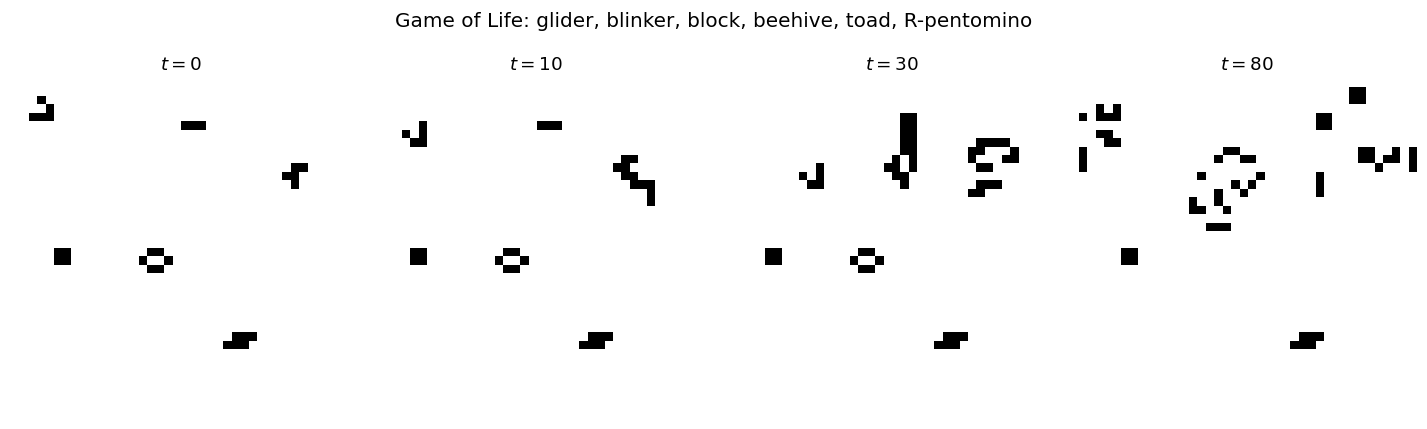

In [4]:
def gol_step(X):
    """One step of Conway's Game of Life on a toroidal grid."""
    N = sum(
        np.roll(np.roll(X, di, axis=0), dj, axis=1)
        for di in (-1, 0, 1) for dj in (-1, 0, 1)
        if (di, dj) != (0, 0)
    )
    return ((N == 3) | ((X == 1) & (N == 2))).astype(np.uint8)


def run_gol(X0, steps=50):
    frames = [X0.copy()]
    X = X0.copy()
    for _ in range(steps):
        X = gol_step(X)
        frames.append(X.copy())
    return frames


# ── Canonical patterns ──────────────────────────────────────────────────────
n = 40

def place(grid, pattern, r, c):
    """Place a binary pattern (list of strings) at row r, col c."""
    for dr, row in enumerate(pattern):
        for dc, ch in enumerate(row):
            grid[(r + dr) % grid.shape[0], (c + dc) % grid.shape[1]] = (ch == 'O')

# Glider
glider = [".O.", "..O", "OOO"]
# Blinker (period 2)
blinker = ["OOO"]
# Block (still life)
block = ["OO", "OO"]
# Beehive (still life)
beehive = [".OO.", "O..O", ".OO."]
# Toad (period 2)
toad = [".OOO", "OOO."]
# R-pentomino (long transient)
rpentomino = [".OO", "OO.", ".O."]

# ── Demonstration grid ───────────────────────────────────────────────────────
G = np.zeros((n, n), dtype=np.uint8)
place(G, glider, 2, 2)
place(G, blinker, 5, 20)
place(G, block, 20, 5)
place(G, beehive, 20, 15)
place(G, toad, 30, 25)
place(G, rpentomino, 10, 32)

frames = run_gol(G, steps=80)

# Show t = 0, 10, 30, 80
show_at = [0, 10, 30, 80]
fig, axes = plt.subplots(1, 4, figsize=(12, 3.5))
for ax, t in zip(axes, show_at):
    ax.imshow(frames[t], cmap="binary", interpolation="nearest")
    ax.set_title(f"$t = {t}$", fontsize=11)
    ax.axis("off")
fig.suptitle("Game of Life: glider, blinker, block, beehive, toad, R-pentomino",
             y=1.02)
plt.tight_layout()
plt.show()

## Interactive Game of Life viewer

Step through the evolution of a random initial configuration using the slider. Notice how order and chaos coexist: large random initial states typically evolve into a mixture of stable structures, oscillators, and — occasionally — gliders travelling across the grid.

## Population dynamics

Starting from a random state, the number of live cells typically decays rapidly as unstable configurations die out, then stabilizes around a lower level dominated by still lifes and oscillators. This transient phase captures the *edge-of-chaos* character of the Game of Life.

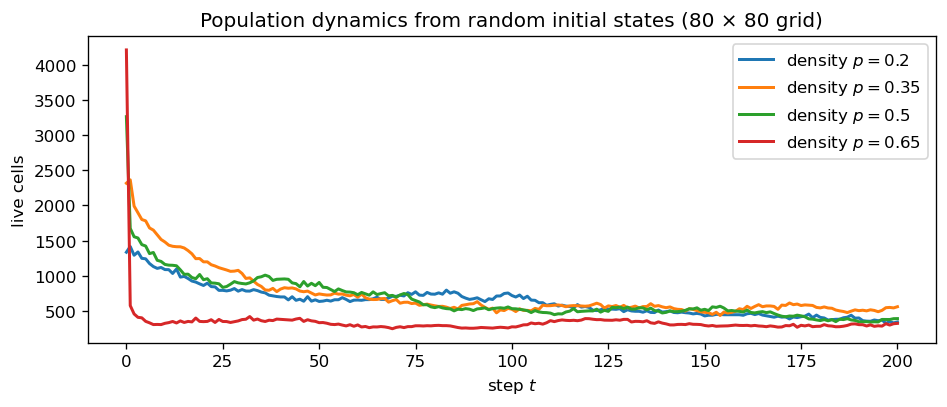

In [5]:
fig, ax = plt.subplots(figsize=(8, 3.5))
densities = [0.2, 0.35, 0.5, 0.65]
steps_pop = 200
for d in densities:
    rng2 = np.random.default_rng(42)
    G0 = (rng2.random((80, 80)) < d).astype(np.uint8)
    pop = [G0.sum()]
    Gc = G0.copy()
    for _ in range(steps_pop):
        Gc = gol_step(Gc)
        pop.append(Gc.sum())
    ax.plot(pop, lw=1.8, label=f"density $p={d}$")

ax.set_xlabel("step $t$")
ax.set_ylabel("live cells")
ax.set_title("Population dynamics from random initial states (80 × 80 grid)")
ax.legend()
plt.tight_layout()
plt.show()

## Bibliographical resources

- Wolfram, S. (1983). Statistical mechanics of cellular automata. *Reviews of Modern Physics*, 55(3), 601.
- Wolfram, S. (2002). *A New Kind of Science*. Wolfram Media.
- Gardner, M. (1970). Mathematical games: The fantastic combinations of John Conway's new solitaire game \"life\". *Scientific American*, 223(4), 120–123.
- Cook, M. (2004). Universality in elementary cellular automata. *Complex Systems*, 15(1), 1–40. (Rule 110 is Turing-complete.)
- Berlekamp, E. R., Conway, J. H., and Guy, R. K. (1982). *Winning Ways for Your Mathematical Plays*. Academic Press.